# Customer Churn and Revenue Risk Analysis

## Business Objective

The objective of this project is to identify the customer segments,
subscription characteristics and service experience factors associated
with customer churn in an OTT subscription business.

The analysis answers the following questions:

- What is the overall churn rate?
- Which plans and contract types experience the highest churn?
- How do complaints, escalations and CSAT relate to churn?
- What are the most common cancellation reasons?
- How much monthly recurring revenue is lost because of churn?
- Which customer segments should be prioritised for retention?

## Churn Definition

A customer is considered churned when `cancellation_date` is available.
Otherwise, the customer is considered active.

## Dataset

The synthetic dataset contains customer-level information from three
relational SQLite tables:

- `db_customer`: customer profile and demographics
- `db_subscription`: subscription, plan, contract and cancellation details
- `db_support`: complaints, escalations and CSAT records

## Tools

SQLite, SQL, Python, pandas, NumPy, Matplotlib and Seaborn.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Data Extraction

In [2]:
# database connection
db_path = Path("../data/customer_churn_100_rows.db")
conn = sqlite3.connect(db_path)

sql_query=""" 
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

tables=pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created datframe: df_{table_name}")

conn.close()


Created datframe: df_db_customer
Created datframe: df_db_subscription
Created datframe: df_db_support


In [3]:
print("Customer table:", df_db_customer.shape)
print("Subscription table:", df_db_subscription.shape)
print("Support table:", df_db_support.shape)

Customer table: (100, 8)
Subscription table: (100, 11)
Support table: (58, 6)


### 1.1 Database Tables and Columns

In [4]:
db_path = Path("../data/customer_churn_100_rows.db")
conn = sqlite3.connect(db_path)


for table_name in tables['name']:
    print(f"\n Table Name: {table_name}")
    columns_query= f"PRAGMA table_info({table_name});"
    columns= pd.read_sql(columns_query,conn)
    print(columns['name'].to_list())

conn.close()
    


 Table Name: db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


## 2. Initial Data Quality Assessment

In [5]:
# a raw-data quality section before cleaning

def inspect_dataframe(name, dataframe):
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", dataframe.shape)
    print("Duplicate rows:", dataframe.duplicated().sum())
    print("Duplicate customer IDs:", dataframe["customerid"].duplicated().sum())
    print("\nData types:")
    print(dataframe.dtypes)
    print("\nMissing values:")
    print(dataframe.isna().sum())


inspect_dataframe("Customer Table", df_db_customer)
inspect_dataframe("Subscription Table", df_db_subscription)
inspect_dataframe("Support Table", df_db_support)


Customer Table
--------------
Shape: (100, 8)
Duplicate rows: 0
Duplicate customer IDs: 0

Data types:
customerid     object
name           object
country        object
state          object
gender         object
dob            object
interests      object
pincode       float64
dtype: object

Missing values:
customerid     0
name           0
country        0
state          0
gender         0
dob            0
interests     44
pincode       21
dtype: int64

Subscription Table
------------------
Shape: (100, 11)
Duplicate rows: 0
Duplicate customer IDs: 0

Data types:
customerid                  object
subscription_start_date     object
subscription_type           object
renewal_date                object
plan_type                   object
contract_type               object
cancellation_date           object
cancellation_reason         object
monthly_charges            float64
cltv                         int64
churn_score                  int64
dtype: object

Missing values:
customerid 

The customer and subscription tables are expected to contain one row per
customer. The support table may contain multiple complaint events per customer,
so duplicate customer IDs in the support table are not necessarily data errors.
They represent a one-to-many relationship.

## 3. Data Cleaning

In [6]:
df_db_customer.shape

(100, 8)

### 3.1 Customer Table Cleaning

In [7]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [8]:
#1.  rename name customer_name
df_db_customer.rename(columns= {'name' : 'customer_name'},inplace= True)

# 2. remove 2 column i.e intrest and pincode
df_db_customer.drop(
    columns=['interests','pincode'],inplace=True, errors="ignore")

# 3.dob to datetime
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'], errors="coerce")

# 4.unique gender name
df_db_customer['gender']=df_db_customer['gender'].replace({'Men': 'Male','Woman': 'Female'})

# 5. Remove leading and trailing spaces
df_db_customer["customer_name"] = (
    df_db_customer["customer_name"]
    .str.strip()
    .str.title()
)

df_db_customer["country"] = df_db_customer["country"].str.strip()
df_db_customer["state"] = df_db_customer["state"].str.strip()

In [9]:
assert df_db_customer["customerid"].is_unique
assert df_db_customer["customerid"].notna().all()

print(df_db_customer.shape)
df_db_customer.head()

(100, 6)


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,Keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,Raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,Lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,Mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,Mira,India,Delhi,Female,1990-05-05


### 3.2 Subscription Table Cleaning

In [10]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               100 non-null    object 
 1   subscription_start_date  100 non-null    object 
 2   subscription_type        100 non-null    object 
 3   renewal_date             100 non-null    object 
 4   plan_type                100 non-null    object 
 5   contract_type            100 non-null    object 
 6   cancellation_date        37 non-null     object 
 7   cancellation_reason      37 non-null     object 
 8   monthly_charges          100 non-null    float64
 9   cltv                     100 non-null    int64  
 10  churn_score              100 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 8.7+ KB


In [11]:
#subscription_start_date datatype changed from object to datetime for single column
df_db_subscription['subscription_start_date']=pd.to_datetime(df_db_subscription['subscription_start_date'],errors='coerce')

# multiple datatype change for renewal_date,cancellation_date
date_col=['renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime,errors='coerce')

# replacing the Refferal to Referral
df_db_subscription["subscription_type"] = (
    df_db_subscription["subscription_type"]
    .replace({"Refferal": "Referral"})
    .str.strip()
)


### 3.3 Support Table Cleaning

In [12]:
df_db_support.info()

df_db_support.shape

df_db_support.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      58 non-null     object
 1   complaint_date  58 non-null     object
 2   escalations     58 non-null     object
 3   csat_score      58 non-null     int64 
 4   col_1           0 non-null      object
 5   comment         38 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.8+ KB


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [13]:
#1. complaint_date datatype change
df_db_support['complaint_date']= pd.to_datetime(df_db_support['complaint_date'])

#2  drop col_1
df_db_support.drop(columns='col_1',inplace = True)

In [14]:
print("Support Rows: ", len(df_db_support))

print("Customers with support records:",df_db_support['customerid'].nunique())
complaint_frequency = (
    df_db_support.groupby('customerid').size()
)

multiple_complaint_customers = (
    complaint_frequency > 1
).sum()

print(
    "Customers with multiple complaint records:",
    multiple_complaint_customers
)

Support Rows:  58
Customers with support records: 44
Customers with multiple complaint records: 12


In [15]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep ='last')

### Support-table consolidation

The support table contains multiple complaint records for some customers.

Before merging, I calculated the total complaint count for each customer and
retained the most recent complaint record. This created one support row per
customer and prevented duplicate customer rows during the join.

Therefore:

- `complaint_count` represents the total number of recorded complaints.
- `complaint_date`, `escalations` and `csat_score` represent the latest
  complaint record.

In [16]:
df_db_subscription['churn_flag']= np.where(df_db_subscription['cancellation_date'].notna(),1,0)

## 4. Data Integration and Validation

In [17]:
#joining the tables
df=(df_db_subscription
        .merge(df_db_customer, on = 'customerid', how = 'left')
        .merge(df_db_support, on = 'customerid', how = 'left'))

In [18]:
print(df.shape)
print(df['customerid'].duplicated().sum())

(100, 22)
0


The final dataset contains one row per customer. The merge retained all
100 subscription customers without creating duplicate customer IDs.

In [19]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,comment,complaint_count
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,Keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,Raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.00,demaned refund,2.00
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,Lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,Mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,Mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.00,None,1.00


### 4.1 Export Cleaned Dataset

In [20]:
# Export cleaned data to CSV

output_path = Path("../data/customer_churn_100_rows_final.csv")

df.to_csv(output_path, index=False)

print("Cleaned file exported successfully")

Cleaned file exported successfully


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               100 non-null    object        
 1   subscription_start_date  100 non-null    datetime64[ns]
 2   subscription_type        100 non-null    object        
 3   renewal_date             100 non-null    datetime64[ns]
 4   plan_type                100 non-null    object        
 5   contract_type            100 non-null    object        
 6   cancellation_date        37 non-null     datetime64[ns]
 7   cancellation_reason      37 non-null     object        
 8   monthly_charges          100 non-null    float64       
 9   cltv                     100 non-null    int64         
 10  churn_score              100 non-null    int64         
 11  churn_flag               100 non-null    int64         
 12  customer_name            100 non-null

In [22]:
df.isnull().sum()

customerid                  0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          63
cancellation_reason        63
monthly_charges             0
cltv                        0
churn_score                 0
churn_flag                  0
customer_name               0
country                     0
state                       0
gender                      0
dob                         0
complaint_date             56
escalations                56
csat_score                 56
comment                    73
complaint_count            56
dtype: int64

In [23]:
df['customerid'].duplicated().sum()

np.int64(0)

In [24]:
df.shape

(100, 22)

# Data Analysis

## 5. Overall Churn and Revenue KPIs

In [25]:
total_customer = df['customerid'].nunique() 
print("Total Customer: ",total_customer)

churned_customer = df['churn_flag'].sum()
print("Total Churned Customer: ",churned_customer)

active_customer = total_customer - churned_customer
print("Total Active customer",active_customer)

# Overall churn rate
churn_rate = df['churn_flag'].mean() * 100
print("Overall churn rate: ",round(churn_rate), "%")

# Retention_rate
retention_rate = 100 - churn_rate
print("Overall retention rate:",round(retention_rate, 2),"%")

# Total monthly charges
total_monthly_charges = df['monthly_charges'].sum()
print("Total monthly charge: ",round(total_monthly_charges,2))

# Monthly charges lost from churned customers
lost_monthly_charge = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Monthly charges lost from churned customers", lost_monthly_charge)

# percentage of monthly revenue lost
monthly_revenue_loss_pct = (lost_monthly_charge / total_monthly_charges) * 100
print("Monthly revenue loss percentage:", round(monthly_revenue_loss_pct,2),"%")

Total Customer:  100
Total Churned Customer:  37
Total Active customer 63
Overall churn rate:  37 %
Overall retention rate: 63.0 %
Total monthly charge:  2069.0
Monthly charges lost from churned customers 579.63
Monthly revenue loss percentage: 28.01 %


## 6. Subscription and Contract Analysis

### 6.1 Churn by Plan Type

In [26]:
plan_analysis = (df.groupby('plan_type').agg(
            total_customers=('customerid','count'),
            churned_customers=('churn_flag','sum'),
            avg_monthly_charges=('monthly_charges','mean'),
            total_monthly_charges=('monthly_charges', 'sum')
            
        ).reset_index()
)
plan_analysis['churn_rate_pct']= ((plan_analysis['churned_customers']/ plan_analysis['total_customers']) *100).round(2)

plan_analysis = plan_analysis.sort_values('churn_rate_pct', ascending = False)
plan_analysis

,plan_type,total_customers,churned_customers,avg_monthly_charges,total_monthly_charges,churn_rate_pct
2,Standard,41,20,14.97,613.59,48.78
0,Basic,32,11,11.80,377.68,34.38
1,Premium,27,6,39.92,1077.73,22.22


**Observation:** Standard-plan customers have the highest churn rate. Premium has the lowest churn rate.

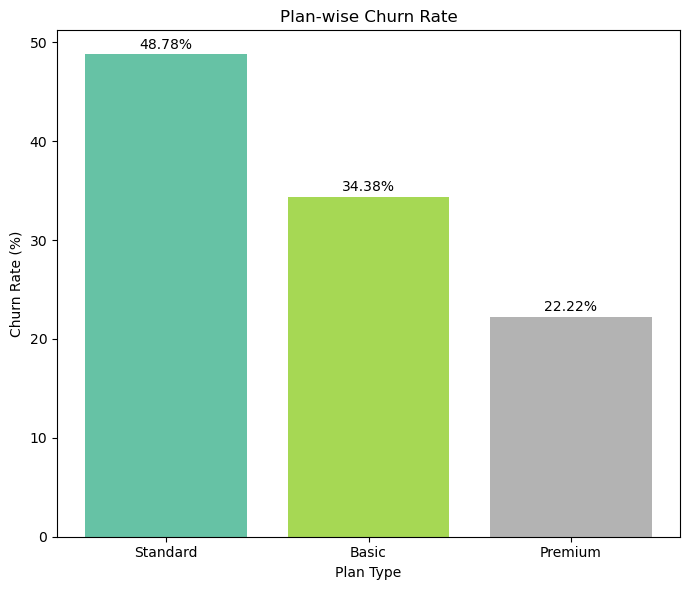

In [27]:
#plan_analysis = plan_analysis.reset_index()

colors = plt.cm.Set2(
    np.linspace(0, 1, len(plan_analysis))
)

plt.figure(figsize=(7, 6))

bars = plt.bar(
    plan_analysis['plan_type'],          # X-axis: plan names
    plan_analysis['churn_rate_pct'],     # Y-axis: churn percentage
    color=colors
)

plt.title('Plan-wise Churn Rate')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.bar_label(bars, fmt='%.2f%%', padding=2)
plt.tight_layout()

# Save the graph

plt.savefig(
    '../images/plan_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### 6.2 Churn by Contract Type

In [28]:
#total cystomer, b. curned customer, avg_monthy_revenue, loss_monthly_revenue, churn_rate_pct

contract_type_analysis= (df.groupby('contract_type').agg(
                        total_customer = ('customerid','count'),
                        churned_customer= ('churn_flag', 'sum'),
                        avg_monthly_rev= ('monthly_charges','mean'),
                        total_monthly_rev= ('monthly_charges','sum')
            ).reset_index()
)
contract_type_analysis['churn_rate_pct']= ((contract_type_analysis['churned_customer']/ contract_type_analysis['total_customer']) *100).round(2)
contract_type_analysis=contract_type_analysis.sort_values('churn_rate_pct', ascending = False)

**Observation:** Monthly contract customers churn almost twice as frequently as annual contract customers.

A useful business recommendation could be to encourage monthly customers to move to annual contracts.

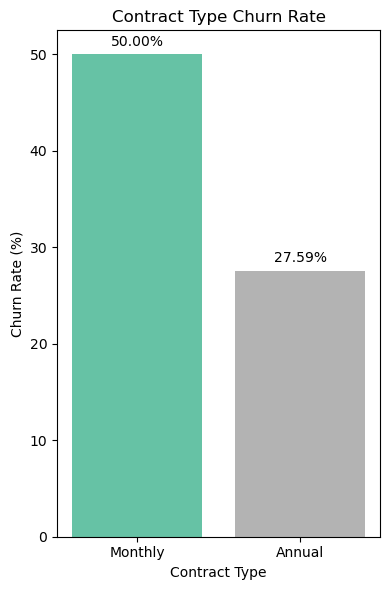

In [29]:
colors = plt.cm.Set2(
    np.linspace(0, 1, len(contract_type_analysis))
)
plt.figure(figsize=(4,6))

bars=plt.bar(
    contract_type_analysis['contract_type'],
    contract_type_analysis['churn_rate_pct'],
    color =colors
)

plt.title('Contract Type Churn Rate')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.bar_label(bars,fmt= '%.2f%%',padding=4)
plt.tight_layout()


plt.savefig(
    '../images/contract_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### 6.3 Churn by Plan and Contract Combination

In [30]:
contract_plan_anlysis = pd.crosstab(df['plan_type'],
           df['contract_type'],
           values=df['churn_flag'],
           aggfunc='mean')*100
contract_plan_anlysis.style.format('{:.1f}%')

contract_type,Annual,Monthly
plan_type,,
Basic,26.7%,41.2%
Premium,15.0%,42.9%
Standard,39.1%,61.1%


**Important segment:** Standard plan customers with monthly contracts have approximately 61.1% churn.

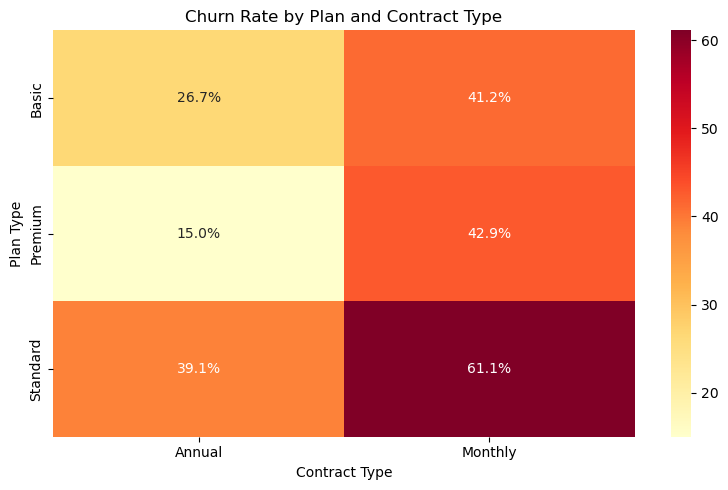

In [31]:
# contract_plan_anlysis by heatmap
labels = contract_plan_anlysis.map(lambda x: f'{x:.1f}%')
plt.figure(figsize=(8,5))

sns.heatmap(contract_plan_anlysis,
           annot= labels,
            fmt= '',
             cmap='YlOrRd'
           )

plt.title('Churn Rate by Plan and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Plan Type')
plt.tight_layout()

plt.savefig(
    '../images/plan_contract_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### 6.4 Churn by Acquisition Source

In [32]:

subscription_churn_analyse= (df.groupby('subscription_type').agg(
                total_customers=( 'customerid','count'),
                churn_customer= ('churn_flag','sum')
).reset_index()
                            )

subscription_churn_analyse['churn_rate']= ((subscription_churn_analyse['churn_customer']/subscription_churn_analyse['total_customers']) *100).round(2)

subscription_churn_analyse = subscription_churn_analyse.sort_values('churn_rate', ascending =False)
subscription_churn_analyse

,subscription_type,total_customers,churn_customer,churn_rate
2,Referral,27,12,44.44
1,Paid,34,14,41.18
0,Organic,39,11,28.21


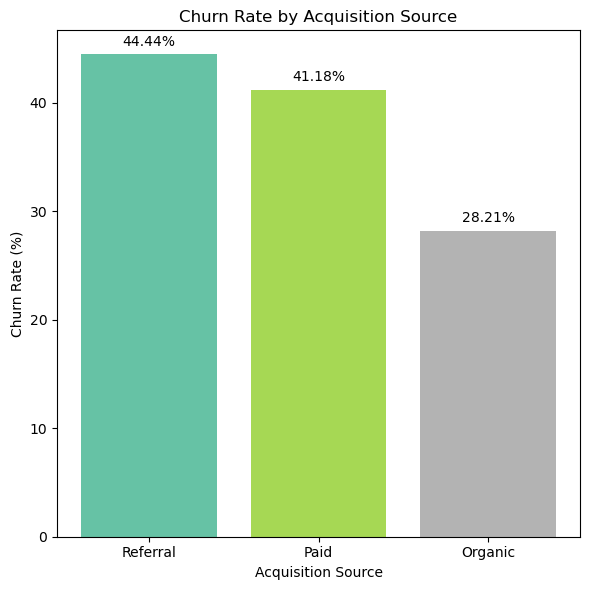

In [33]:
colors= plt.cm.Set2(
    np.linspace(0, 1, len(subscription_churn_analyse))
)
plt.figure(figsize=(6,6))

bars=plt.bar(subscription_churn_analyse['subscription_type'],
             subscription_churn_analyse['churn_rate'],
             color= colors)

plt.title('Churn Rate by Acquisition Source')
plt.xlabel('Acquisition Source')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.bar_label(bars,fmt= '%.2f%%',padding=4)
plt.tight_layout()


plt.savefig(
    '../images/acquisition_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 7. Customer Support Experience and Churn

### 7.1 Complaints and Churn

In [34]:
df['has_complaint'] = df['complaint_date'].notna()

complaints_analyse= (
    df.groupby('has_complaint')
    .agg(
    customer_count= ('customerid','count'),
    churn_customer=('churn_flag','sum'),
    avg_churn_score= ('churn_score','mean')
      )
    .reset_index()
)

complaints_analyse = complaints_analyse.rename(
                    columns={'has_complaint':'customer group'}
)              
complaints_analyse['customer group']= complaints_analyse['customer group'].map({
    False:'No Complaint Record',
    True :'Complaint Record'
})
complaints_analyse['churn_rate_pct']=((complaints_analyse['churn_customer']/complaints_analyse['customer_count'])*100).round(2)

complaints_analyse = complaints_analyse.sort_values('churn_rate_pct', ascending =False)
complaints_analyse.style.format({
    'avg_churn_score': '{:.2f}',
    'churn_rate_pct': '{:.1f}%'
})

,customer group,customer_count,churn_customer,avg_churn_score,churn_rate_pct
1,Complaint Record,44,34,72.89,77.3%
0,No Complaint Record,56,3,37.02,5.4%


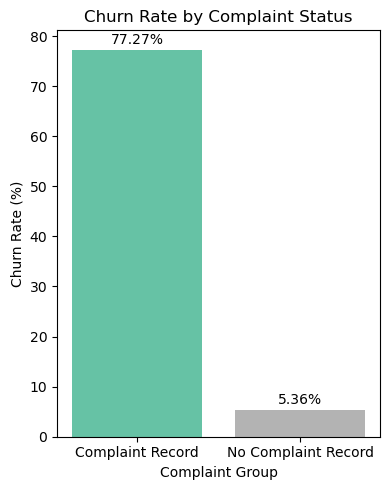

In [35]:
colors= plt.cm.Set2(
    np.linspace(0, 1, len(complaints_analyse))
)
plt.figure(figsize=(4,5))

bars=plt.bar(complaints_analyse['customer group'],complaints_analyse['churn_rate_pct'], color=colors )

plt.title('Churn Rate by Complaint Status')
plt.xlabel('Complaint Group')
plt.ylabel('Churn Rate (%)')

plt.bar_label(bars,fmt='%.2f%%',padding=2)
plt.tight_layout()

plt.savefig(
    '../images/Complaint_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Observation: Complaints and Customer Churn**

Customers with a recorded complaint show a significantly higher churn rate than customers with no complaint record.

Out of 44 customers who raised a complaint, 34 customers churned, resulting in a churn rate of 77.3%. In comparison, only 3 out of 56 customers without a recorded complaint churned, giving a much lower churn rate of 5.4%.

The average churn score is also higher for customers with complaints at 72.89, compared with 37.02 for customers without complaints.

This indicates a strong association between customer complaints and churn. Customers who raise complaints are more likely to be dissatisfied and cancel their subscriptions. Therefore, the company should prioritize faster complaint resolution and closely monitor customers with complaints to reduce churn.

### 7.2 Escalations and Churn

In [36]:
escalation_analyse=(
    df[df['escalations'].notna()].
    groupby('escalations').agg(
    customer_count=('customerid','count'),
    churn_customer=('churn_flag','sum'),
    avg_CSAT=('csat_score','mean')
    ).reset_index()
)
escalation_analyse= escalation_analyse.rename(
    columns={'escalations' : 'Escalation'}
)

escalation_analyse['Escalation']=escalation_analyse['Escalation'].map({
    'N' :'No',
    'Y': 'Yes'
})

escalation_analyse['churn_rate']= ((escalation_analyse['churn_customer']/escalation_analyse['customer_count'])*100).round(2)



escalation_analyse=escalation_analyse.sort_values('churn_rate', ascending =False)

escalation_analyse.style.format({
    'avg_CSAT' : '{:.2f}',
    'churn_rate' : '{:.1f}%'
})

,Escalation,customer_count,churn_customer,avg_CSAT,churn_rate
1,Yes,20,19,40.25,95.0%
0,No,24,15,54.38,62.5%


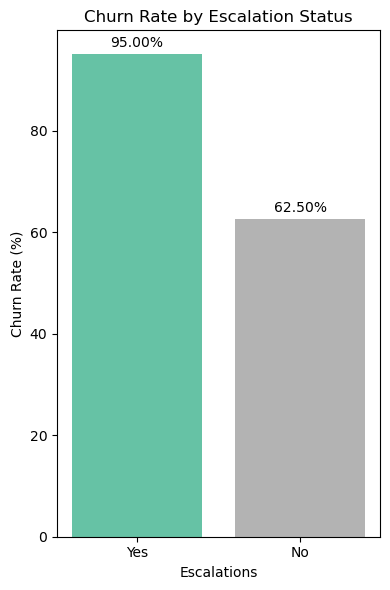

In [37]:
colors=plt.cm.Set2(
    np.linspace(0, 1, len(escalation_analyse))
)

plt.figure(figsize=(4,6))

bars= plt.bar(escalation_analyse['Escalation'],escalation_analyse['churn_rate'], color=colors )

plt.title('Churn Rate by Escalation Status')
plt.xlabel('Escalations')
plt.ylabel('Churn Rate (%)')

plt.bar_label(bars, fmt='%.2f%%',padding=3)
plt.tight_layout()

plt.savefig(
    '../images/Escalation_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Observation: Escalations and Churn

Customers whose complaints were escalated had a churn rate of 95.0%,
compared with 62.5% for customers whose complaints were not escalated.

Escalated customers also had a lower average CSAT score of 40.25,
compared with 54.38 for non-escalated customers.

This shows a strong association between serious unresolved complaints,
lower satisfaction and customer churn. Escalation should not be treated
as the direct cause of churn because customers may escalate after already
experiencing significant service problems.

### 7.3 CSAT and Churn

In [38]:
df['csat_category'] = pd.cut(
    df['csat_score'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

csat_analyze = (df.groupby('csat_category', observed=False).agg(
    customer_count=('customerid','count'),
    churned_customer=('churn_flag','sum')
    ).reset_index()
)
csat_analyze['churn_rate_pct'] = (csat_analyze['churned_customer']/csat_analyze['customer_count']) *100

csat_analyze.style.format({
    'churn_rate_pct': '{:.2f}%'
}
)

,csat_category,customer_count,churned_customer,churn_rate_pct
0,Low,23,21,91.30%
1,Medium,10,9,90.00%
2,High,11,4,36.36%


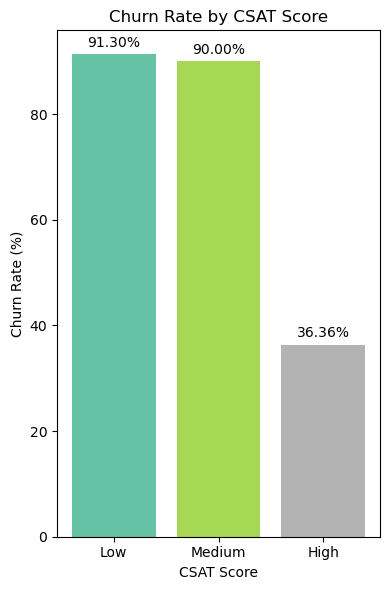

In [39]:
colors=plt.cm.Set2(
    np.linspace(0, 1, len(csat_analyze))
)

plt.figure(figsize=(4,6))

bars= plt.bar(csat_analyze['csat_category'],csat_analyze['churn_rate_pct'], color=colors )

plt.title('Churn Rate by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Churn Rate (%)')

plt.bar_label(bars, fmt='%.2f%%',padding=3)
plt.tight_layout()

plt.savefig(
    '../images/CSAT_score_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

CSAT is available only for customers with support records. Therefore,
this analysis represents customers who contacted support, not the complete
customer population.

## 8. Cancellation Reason Analysis

### 8.1 Most Common Cancellation Reasons

In [40]:
cancellation_reason_analyze= (df[df['churn_flag']==1]
                    ['cancellation_reason'].
                    value_counts().
                     reset_index()
     )


cancellation_reason_analyze

,cancellation_reason,count
0,Switched to competitor,8
1,Forgot to cancel trial,6
2,Payment problem,6
3,Not enough content,5
4,Technical issues,5
5,Poor streaming quality,3
6,Too expensive,2
7,Not using the service,2


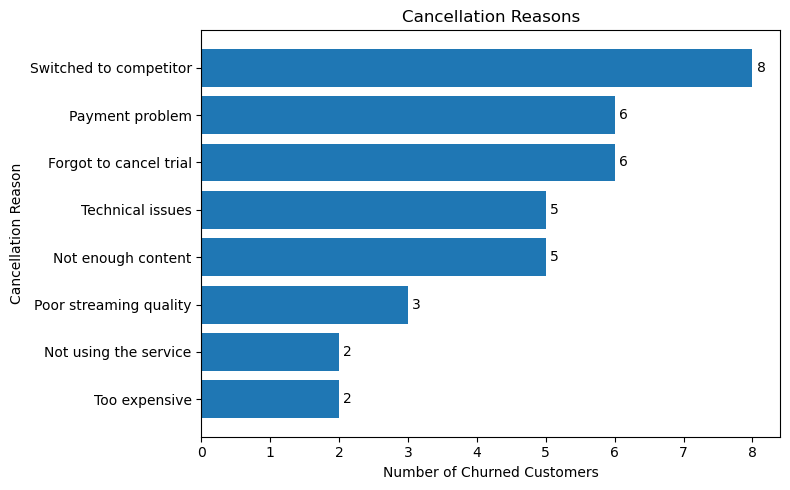

In [41]:
plot_data = cancellation_reason_analyze.sort_values(
    'count',
    ascending=True
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    plot_data['cancellation_reason'],
    plot_data['count']
)

plt.bar_label(bars, padding=3)

plt.title('Cancellation Reasons')
plt.xlabel('Number of Churned Customers')
plt.ylabel('Cancellation Reason')
plt.tight_layout()

plt.savefig(
    '../images/cancellation_reason.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### 8.2 Revenue Loss by Cancellation Reason

In [42]:
df.groupby('cancellation_reason')['monthly_charges'].sum().sort_values(ascending= False)

cancellation_reason
Switched to competitor   119.92
Forgot to cancel trial    92.94
Technical issues          88.95
Not using the service     73.98
Not enough content        73.95
Payment problem           71.94
Poor streaming quality    35.97
Too expensive             21.98
Name: monthly_charges, dtype: float64

### Observation: Cancellation Reasons

Switching to a competitor was the most common cancellation reason,
reported by 8 customers. It also caused the highest monthly revenue loss
of 119.92.

Payment problems and forgotten trial cancellations affected 6 customers
each, indicating that some churn may be related to billing and subscription
management rather than dissatisfaction with price alone.

### 8.3 Cancellation Reasons by Plan Type

In [43]:
pd.crosstab(
    df['cancellation_reason'],
    df['plan_type']
)

plan_type,Basic,Premium,Standard
cancellation_reason,,,
Forgot to cancel trial,4,1,1
Not enough content,1,0,4
Not using the service,0,1,1
Payment problem,2,0,4
Poor streaming quality,0,0,3
Switched to competitor,4,2,2
Technical issues,0,2,3
Too expensive,0,0,2


## 9. Customer Tenure Analysis

### 9.1. Average Tenure Days

snapshot_tenure:
The dataset is treated as a snapshot as of 31 December 2026. For active customers, tenure is measured from the subscription start date to this snapshot date. For churned customers, tenure is measured up to their cancellation date.

In [44]:
snapshot_tenure= pd.Timestamp("2026-12-31")
df['tenure_days'] = np.where(df['cancellation_date'].notna(),
                             (df['cancellation_date']- df['subscription_start_date']).dt.days,
                             (snapshot_tenure-df['subscription_start_date']).dt.days
                            )

avg_tenure_days=df['tenure_days'].mean()

print('Average Tenure Days: ',avg_tenure_days)

Average Tenure Days:  1653.66


### 9.2. Active and Churned Customer Tenure Distribution

In [45]:
df['subscription_end_date']= (df['cancellation_date'].
                        fillna(snapshot_tenure)
                             )

df['tenure_month']= ((df['subscription_end_date']- df['subscription_start_date']).dt.days/30.44).round()

df['Customer Category']= df['churn_flag'].map({
    0: 'Active Customer',
    1: 'Churned Customer'
})
tenure_customer=df.groupby('Customer Category')['tenure_month'].agg(
    ['mean','median']
).reset_index()


tenure_customer.style.format({
    'mean' : '{:.2f}',
    'median': '{:.2f}'
})



,Customer Category,mean,median
0,Active Customer,67.17,67.00
1,Churned Customer,32.51,37.00


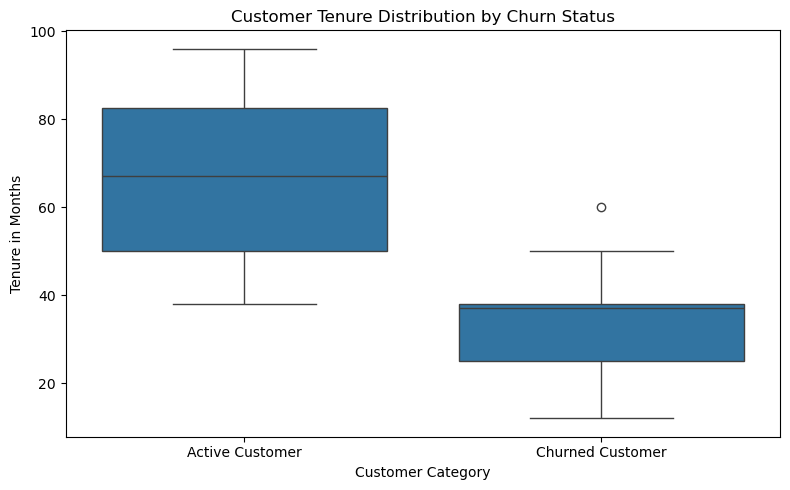

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Customer Category',
    y='tenure_month'
)
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Customer Category')
plt.ylabel('Tenure in Months')
plt.tight_layout()

plt.savefig(
    '../images/tenure_distribution_churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

**Observation:**
Churned customers had a substantially shorter average tenure of 32.51 months, compared with 67.17 months for active customers, suggesting that churn is more concentrated among shorter tenure customers.

## 10. Revenue Impact Analysis

### 10.1 Loss Revenue Plan Type

In [47]:
lost_revenue_monthly =(df[df['churn_flag']==1].groupby('plan_type')['monthly_charges']
                        .sum()
                        .sort_values(ascending=False)).reset_index()


annual_lost_revenue_by_plan = lost_revenue_monthly.copy()

annual_lost_revenue_by_plan['annualized_revenue_loss'] = (
    annual_lost_revenue_by_plan['monthly_charges'] * 12
)

print(
    "Monthly & Annual Lost Revenue by Plan Type:\n",
    annual_lost_revenue_by_plan)



Monthly & Annual Lost Revenue by Plan Type:
   plan_type  monthly_charges  annualized_revenue_loss
0  Standard           278.80                  3345.60
1   Premium           155.94                  1871.28
2     Basic           144.89                  1738.68


### 10.2 Estimated Monthly & Annual revenue loss from churn?

In [48]:
# What is the estimated annual revenue loss from churn?
total_monthly_revenue_loss = (lost_revenue_monthly["monthly_charges"].sum()).round(2)

total_annualized_revenue_loss = ((lost_revenue_monthly['monthly_charges'] .sum())*12).round(2)

print("Total monthly revenue loss from churn:",total_monthly_revenue_loss)
print("Estimated annualized revenue loss from churn: ", total_annualized_revenue_loss)

Total monthly revenue loss from churn: 579.63
Estimated annualized revenue loss from churn:  6955.56


### 10.3. CLTV (Customer Life Time Value) Analysis

In [49]:
cltv_analysis = (
    df.groupby('Customer Category')
    .agg(
        customer_count=('customerid', 'nunique'),
        average_cltv=('cltv', 'mean'),
        total_cltv=('cltv', 'sum')
    )
    .reset_index()
)

cltv_analysis


,Customer Category,customer_count,average_cltv,total_cltv
0,Active Customer,63,1032.62,65055
1,Churned Customer,37,614.70,22744


**Observation:**

Active customers had an average CLTV of 1,032.62, compared with 614.70 for churned customers. The average CLTV of churned customers was approximately 40.5% lower, showing that retained customers represent substantially greater long-term value.

## 11. Churn Score Analysis

In [50]:
df['Customer Category']= df['churn_flag'].map({
    0: 'Active Customer',
    1: 'Churned Customer'
})

df.groupby('Customer Category')['churn_score'].agg(
    ['mean', 'median', 'min', 'max']
).reset_index()


,Customer Category,mean,median,min,max
0,Active Customer,33.62,33.00,1,68
1,Churned Customer,85.46,84.00,70,99


The churn score was supplied with the dataset and was not created in this
project.

Because active customers have scores up to 68 and churned customers have
scores from 70 onwards, the score may already contain information closely
related to the churn outcome. It is therefore treated as an existing
business risk indicator, not as a predictive model developed in this project.

## 12. Monthly Charges and Churn

In [51]:
df['Customer Category']= df['churn_flag'].map({
    0: 'Active Customer',
    1: 'Churned Customer'
})

monthly_charge_analysis = (df.groupby('Customer Category')['monthly_charges'].agg(
                    [ 'mean','median','count'])
                    .round(2)
                    .reset_index()
)

monthly_charge_analysis

,Customer Category,mean,median,count
0,Active Customer,23.64,16.99,63
1,Churned Customer,15.67,13.99,37


**Observation:**
Churned customers had lower monthly charges than active customers. The average monthly charge of churned customers was 15.67, compared with 23.64 for active customers. The median monthly charge also followed the same pattern, at 13.99 for churned customers and 16.99 for active customers. Therefore, this dataset does not support the assumption that customers
with higher monthly charges are more likely to churn.

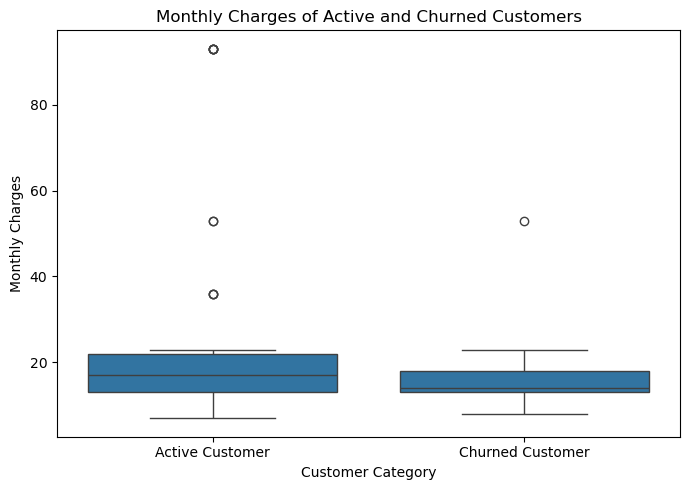

In [52]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Customer Category',
    y='monthly_charges'
)

plt.title('Monthly Charges of Active and Churned Customers')
plt.xlabel('Customer Category')
plt.ylabel('Monthly Charges')
plt.tight_layout()

plt.savefig(
    '../images/monthly_charges_active_churn_customer.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### 12.1. ARPU — Average Revenue per User

In [53]:
active_customers = df[df['churn_flag']==0]
arpu= (active_customers['monthly_charges'].sum() /
      active_customers['customerid'].nunique ())

print('Active Customer ARPU  = ',round(arpu,2))

Active Customer ARPU  =  23.64


## 13. Demographic and Geographic Analysis

### 13.1 Churn by State

In [54]:
state_churn_analyse=(df.groupby('state').agg(
    customer_count = ('customerid', 'count'),
    churned_customer= ('churn_flag','sum')
            ).reset_index()
                   )


state_churn_analyse['churn_rate_pct']= ((state_churn_analyse['churned_customer']/state_churn_analyse['customer_count']) *100).round(2)

state_churn_analyse.sort_values(by=['churn_rate_pct','churned_customer'], ascending=[ False, False])

,state,customer_count,churned_customer,churn_rate_pct
4,Birgunj,2,2,100.00
8,Hetauda,1,1,100.00
9,Janakpur,1,1,100.00
18,Pokhara,6,4,66.67
17,Odisha,3,2,66.67
15,Meghalaya,5,3,60.00
10,Karnataka,6,3,50.00
12,Kerala,4,2,50.00
21,Telangana,4,2,50.00
1,Assam,2,1,50.00


### Observation: State-level Churn

Birgunj, Hetauda and Janakpur show 100% churn, but these results are based
on only one or two customers and should not be treated as reliable
state level trends.

Among states with a relatively larger customer base, Pokhara had a churn
rate of 66.7% with 4 of 6 customers churning, followed by Meghalaya at
60.0% with 3 of 5 customers churning.

The small segment sizes mean that the geographic results should be treated
as directional rather than conclusive.

### 13.2 Churn by Country

In [55]:
country_churn_analyse= (df.groupby('country').agg(
    customer_count = ('customerid','count'),
    churned_customer= ('churn_flag','sum')
        ).reset_index()
                       )

country_churn_analyse['churn_rate_pct']=((country_churn_analyse['churned_customer']/country_churn_analyse['customer_count'])*100).round(2)
country_churn_analyse.sort_values(by='churn_rate_pct',ascending = False)

,country,customer_count,churned_customer,churn_rate_pct
1,Nepal,20,11,55.00
0,India,80,26,32.50


### Observation: Country-level Churn

Nepal had a churn rate of 55.0%, with 11 of 20 customers churning.
India had a lower churn rate of 32.5%, with 26 of 80 customers churning.

The company should investigate whether the higher Nepal churn rate is
associated with service availability, payment options, content preferences
or customer-support experience.

### 13.3 Churn by Gender

In [56]:
gender_churn_analyse = (df.groupby('gender').agg(
    customer_count = ('customerid','count'),
    churned_customer= ('churn_flag','sum')
                        ).reset_index()
                       )
gender_churn_analyse['churn_rate_pct']= ((gender_churn_analyse['churned_customer']/gender_churn_analyse['customer_count'])*100).round(2)
gender_churn_analyse

,gender,customer_count,churned_customer,churn_rate_pct
0,Female,49,16,32.65
1,Male,51,21,41.18


### Observation: Gender and Churn

Male customers had a churn rate of 41.2%, compared with 32.7% for female
customers.

The difference is moderate, and gender alone should not be treated as a
primary churn driver without examining other factors such as plan,
contract, tenure and complaints.

### 13.4 Churn by Age Group

In [57]:
df['age']=(((snapshot_tenure- df['dob']).dt.days)/365.25).astype(int)

df['age_group']=pd.cut(
    df['age'],
    bins=[0,24,35,55,100],
    labels=['Under 25','25-34','35-54','55+'],
    include_lowest =True
)

age_group_churn_anlayse = (df.groupby('age_group', observed=False).agg(
    customer_count= ('customerid', 'count'),
    churned_customer=('churn_flag','sum')
            ).reset_index()
                          )
age_group_churn_anlayse['churn_rate_pct']=((age_group_churn_anlayse['churned_customer']/age_group_churn_anlayse['customer_count'])*100).round(2)

age_group_churn_anlayse.sort_values(by='churn_rate_pct',ascending=False)

,age_group,customer_count,churned_customer,churn_rate_pct
1,25-34,30,12,40.00
2,35-54,38,15,39.47
3,55+,22,8,36.36
0,Under 25,10,2,20.00


### Observation: Age Group and Churn

Customers aged 25–34 had the highest churn rate in the dataset, while
customers under 25 had the lowest churn rate.

This suggests that retention strategies may need to consider the needs
and subscription behaviour of the 25–34 customer segment. However, the
result should be interpreted together with plan, contract and complaint
behaviour.

### 13.5 Churn by Month

In [58]:
df['cancellation_month']= df['cancellation_date'].dt.to_period('M')
month_churn= (df[df['churn_flag']==1].groupby('cancellation_month').agg(
            churned_customer = ('customerid','nunique')
).reset_index()
 .sort_values('churned_customer',ascending= False)
             )
month_churn

,cancellation_month,churned_customer
14,2025-09,4
13,2025-08,3
8,2024-10,3
16,2025-11,3
15,2025-10,3
19,2026-02,2
3,2023-04,2
6,2024-05,2
7,2024-09,2
9,2024-11,2


### Obsevation : Month-wise Cancellations

September 2025 recorded the highest monthly churn, with four customer cancellations. A broader churn concentration was observed between August and November 2025, during which 13 customers cancelled. This period should be investigated for possible service, pricing, renewal or customer-support issues.

# Key Findings

1. The overall customer churn rate was 37%, with 37 churned customers and
   63 active customers.

2. Standard-plan customers had the highest plan-level churn rate at 48.8%.

3. Monthly-contract customers churned at 50.0%, compared with 27.6% for
   annual-contract customers.

4. Standard monthly customers were the highest-risk plan-contract segment,
   with approximately 61.1% churn.

5. Referral customers had the highest acquisition-source churn rate at
   44.4%, followed by Paid customers at 41.2%.

6. Complaint history was strongly associated with churn. Customers with
   complaints had a churn rate of 77.3%, compared with 5.4% for customers
   without recorded complaints.

7. Customers with escalated complaints had a churn rate of 95.0% and lower
   average CSAT than customers whose complaints were not escalated.

8. Switching to a competitor was the most common cancellation reason and
   produced the highest monthly revenue loss.

9. Churned customers accounted for 579.63 in monthly revenue loss,
   representing approximately 28.0% of the total monthly value represented
   in the dataset.

10. The dataset does not support the assumption that higher monthly charges
    produce more churn. Churned customers had lower average and median
    monthly charges than active customers.

# Business Recommendations

1. Prioritise Standard monthly customers for retention campaigns and
   annual-contract conversion offers.

2. Introduce an urgent service-recovery process for escalated complaints.

3. Improve complaint resolution time and proactively follow up with
   customers who report low or medium CSAT.

4. Investigate why customers are switching to competitors, including
   content availability, service quality and competitor offerings.

5. Improve payment-problem handling and send clear reminders before free
   trials or promotional subscriptions expire.

6. Review Referral and Paid acquisition channels based on customer quality
   and retention, not only the number of customers acquired.

7. Treat geographic findings carefully because several states contain very
   small customer samples.

# Project Limitations

- The dataset is synthetic and contains only 100 customers.
- Several demographic and geographic segments contain small samples.
- The analysis identifies associations but does not prove causation.
- CSAT and escalation information is available only for customers who
  contacted support.
- For customers with multiple complaints, the latest complaint details
  were retained while the total complaint count was preserved.
- Annualized revenue loss assumes the monthly loss continues for 12 months.
- The churn score was supplied with the dataset and was not developed in
  this project.